# OLS: relaxing additivity

Suppose we are interested in estimating this CAPM-like equation:

$$
\mathbb{E}(r_t) - r_f = \alpha + \beta_{mkt} mkt_t + \beta_{vix} vix_t + \epsilon_t
$$

The underlying assumption is that $\beta_{mkt}$ is independent of market volatility ($vix_t$). By relaxing the additivity assumption, we instead estimate: 

$$
\mathbb{E}(r_t) - r_f = \alpha + \beta_{mkt} mkt_t + \beta_{vix} vix_t + \gamma mkt_t \times vix_t + \epsilon_t
$$

Our sample consists of:
-  Asset: IBM
- $mkt_t$: S\&P500
- $r_f$: 3-month T-bills
- 2010-01-01 -- 2025-01-01


## 0. Required packages

In [1]:
import yfinance as yf
import statsmodels.api as sm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import numpy as np

## 1. Retrieve and prepate data

We can use the `yfinance` Python package, which takes the following arguments:

- ticker
- start/end

where the IBM, S&P500, and VIX tickers are `IBM`, `^GSPC`, `^VIX`, respectively

In [2]:
ticker = "IBM"
market = "^GSPC"     # or "SPY"
vix = "^VIX"
start = "2010-01-01"
end = "2025-01-01"
fred_rf = "DGS3MO"   # 3-month T-bill (annualized %, daily)
trading_days = 252   # used to convert annualized % to daily decimal

# --------------------
# 1) Download daily prices and compute daily returns
# --------------------
prices = yf.download([ticker, market, vix], start=start, end=end, auto_adjust=True, progress=False)["Close"]


rets = prices.pct_change().dropna()
rets.columns = [c.upper() for c in rets.columns]

# --------------------
# 2) Risk-free daily (approx): annualized % / 100 / 252
# --------------------
rf_daily = pdr.DataReader(fred_rf, "fred", start, end).dropna()
rf_daily["RF"] = rf_daily[fred_rf] / 100.0 / trading_days
rf_daily = rf_daily[["RF"]]


# align everything on common dates
df = rets.join(rf_daily, how="inner").dropna()

# --------------------
# 3) Build regression variables
# --------------------
df["STOCK_EXCESS"] = df[ticker.upper()] - df["RF"]
df["MKT_EXCESS"] = df[market.upper()] - df["RF"]

# VIX term: daily % change in VIX level
vix_level = yf.download(vix, start=start, end=end, auto_adjust=True, progress=False)["Close"]
df["VIX"] = vix_level.pct_change()

df = df.dropna()

# Interaction term
df["MKT_X_VIX"] = df["MKT_EXCESS"] * df["VIX"]

## 2. Estimate the model

We estimate the model using `statsmodels` API. Additionally, we correct for heteroskedasticity and autocorrelation (HAC/Newey-West SE)

In [4]:
# --------------------
# 4) Regressions (daily -> use HAC/Newey-West SE)
# --------------------
maxlags = 5  # ~ one trading week

# CAPM: (r_i - r_f) = alpha + beta_mkt*(r_m - r_f) + eps
X_capm = sm.add_constant(df[["MKT_EXCESS"]])
capm = sm.OLS(df["STOCK_EXCESS"], X_capm).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

print("\n=== CAPM (daily, HAC SE) ===")
print(capm.summary())


# Augmented with interaction: + gamma*(MKT*VIX)
X_int = sm.add_constant(df[["MKT_EXCESS", "VIX", "MKT_X_VIX"]])
aug_int = sm.OLS(df["STOCK_EXCESS"], X_int).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

print("\n=== Augmented (Market + VIX + Interaction, daily, HAC SE) ===")
print(aug_int.summary())

beta0 = aug_int.params["MKT_EXCESS"]
gamma = aug_int.params["MKT_X_VIX"]

# conditional market slope (beta) for each observed VIX move in your sample
df["BETA_COND"] = beta0 + gamma * df["VIX"]

# 95% CI for beta(v) = beta0 + gamma*v using the parameter covariance matrix
V = df["VIX"].to_numpy()
cov = aug_int.cov_params().loc[["MKT_EXCESS", "MKT_X_VIX"], ["MKT_EXCESS", "MKT_X_VIX"]].to_numpy()

var_beta = cov[0, 0] + (V**2) * cov[1, 1] + 2 * V * cov[0, 1]
se_beta = np.sqrt(np.maximum(var_beta, 0))
df["BETA_LO"] = df["BETA_COND"] - 1 * se_beta
df["BETA_HI"] = df["BETA_COND"] + 1 * se_beta

# sort by VIX for a clean curve
d = df[["VIX", "BETA_COND", "BETA_LO", "BETA_HI"]].dropna().sort_values("VIX")
x = 100 * d["VIX"].to_numpy()  # in %
y = d["BETA_COND"].to_numpy()
lo = d["BETA_LO"].to_numpy()
hi = d["BETA_HI"].to_numpy()




=== CAPM (daily, HAC SE) ===
                            OLS Regression Results                            
Dep. Variable:           STOCK_EXCESS   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     1031.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          4.90e-200
Time:                        15:15:09   Log-Likelihood:                 11638.
No. Observations:                3745   AIC:                        -2.327e+04
Df Residuals:                    3743   BIC:                        -2.326e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.246e-05 

## 3. Plot

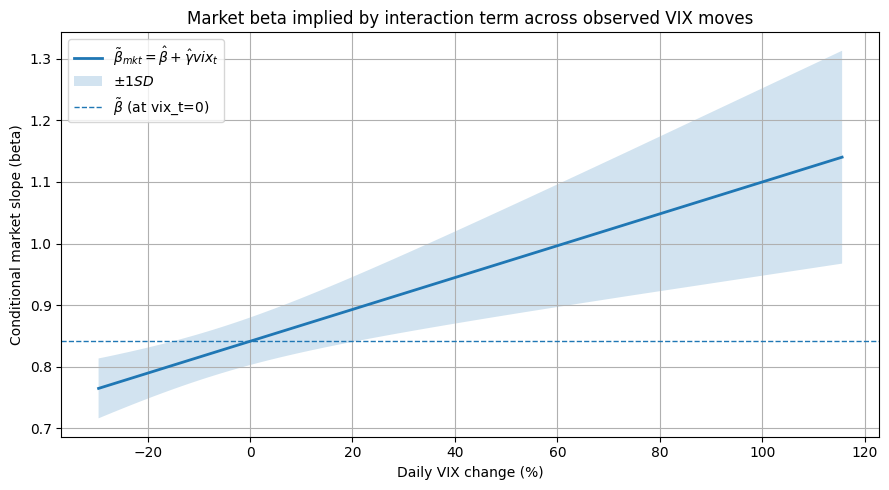

In [5]:

plt.figure(figsize=(9, 5))
plt.plot(x, y, linewidth=2, label=r"$\tilde{\beta}_{mkt}=\hat\beta+\hat\gamma vix_t$")
plt.fill_between(x, lo, hi, alpha=0.2, label=r"$\pm 1 SD$")
plt.axhline(beta0, linestyle="--", linewidth=1, label=r"$\tilde{\beta}$ (at vix_t=0)")
plt.xlabel("Daily VIX change (%)")
plt.ylabel("Conditional market slope (beta)")
plt.title("Market beta implied by interaction term across observed VIX moves")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()
